# Genesys June Interactions Analysis

This notebook loads the exported CSV, runs the textual analysis from `analyzer.py`, and visualises the main metrics.

**Prerequisites**
- Python 3.11+
- Packages: `pandas`, `matplotlib`, `seaborn` (install with `pip install matplotlib seaborn`).
- The notebook lives in the agent's artifact folder, but it explicitly adds the project root to `sys.path` so it can import `loader` and `analyzer`.

In [9]:
import os, sys
# Absolute path to the workspace root (where loader.py / analyzer.py live)
project_root = r"C:/Users/dashayin/Desktop/Work/Genesys June Interactions"
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print('Project root added to sys.path:', project_root)

# Verify imports
try:
    import loader
    import analyzer
    import matplotlib.pyplot as plt
    import seaborn as sns
    %matplotlib inline
    sns.set(style='whitegrid', palette='deep')
    print('All modules imported successfully')
except Exception as e:
    print('Import error:', e)
    raise

Project root added to sys.path: C:/Users/dashayin/Desktop/Work/Genesys June Interactions
All modules imported successfully


In [17]:
# Load the CSV using the project's loader
csv_path = os.path.join(project_root, 'data', 'interactions.csv')
df = loader.load_data(csv_path)
df.head()

📥 Loading dataset from C:/Users/dashayin/Desktop/Work/Genesys June Interactions\data\interactions.csv...
✅ Loaded 34,441 total interaction records across 45 columns.


C:\Users/dashayin/Desktop/Work/Genesys June Interactions\loader.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Parsed_Timestamp'] = pd.to_datetime(df[timestamp_col], errors='coerce')


,Full Export Completed,Partial Result Timestamp,Filters,Media Type,Users,Remote,Date,Duration,Direction,ANI,...,Outcome Success_Clean,Outcome Success %_Clean,Outcome Failure_Clean,Outcome Failure %_Clean,System Error Disconnect_Clean,Flow Disconnect_Clean,All Flow Disconnect_Clean,Customer Disconnect_Clean,Customer Short Disconnect_Clean,Flow Exit_Clean
0,YES,NaN,NaN,message,Laura Coutts,Affy,5/31/26 03:43 AM,50:38:24.085,Inbound,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,YES,NaN,NaN,email,Dale Son,ElectroMechanica,5/31/26 04:00 AM,28:06:26.757,Inbound,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,YES,NaN,NaN,email,Brandon Kessell; Laura Coutts,commercial,5/31/26 05:15 AM,28:42:48.018,Inbound,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,YES,NaN,NaN,email,Carmin Leigh Martin; Nompumelelo Cele,ibreply via Debtors @ EM,5/31/26 08:07 AM,25:27:25.396,Inbound,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,YES,NaN,NaN,email,Tharusha Sewbachane,Jenna,5/31/26 09:55 AM,23:14:40.807,Inbound,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
# Run the textual analysis (prints summary)
analyzer.run_analysis(df)


  🔍 GENESYS PLATFORM JUNE INTERACTIONS COMPREHENSIVE ANALYSIS

----------------------------------------------------------------------
  1. DATA INTEGRITY & OVERVIEW
----------------------------------------------------------------------
Total Exported CSV Records   : 34,441
Dataset Date Range           : 2026-05-31 03:43:00 to 2026-06-30 23:38:00
June 2026 Interaction Count  : 34,415 (99.92% of export dataset)
   └─ (Note: 26 records started on May 31st at end of prior month)
Full Export Completed Flag   : 34,441 (100.00%)

----------------------------------------------------------------------
  2. CHANNEL & DIRECTION BREAKDOWN
----------------------------------------------------------------------

📱 Media Type Distribution:
   - voice          : 22,519 ( 65.38%)
   - email          : 11,677 ( 33.90%)
   - message        :    233 (  0.68%)
   - callback       :     10 (  0.03%)
   - video          :      2 (  0.01%)

🔄 Direction Distribution:
   - Inbound        : 21,939 ( 63.70%)
   -

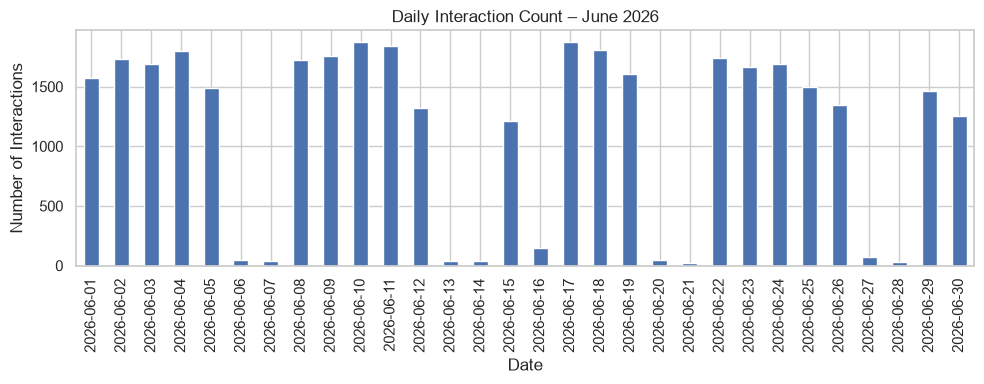

In [12]:
# 1️⃣ Daily interaction count for June 2026
if 'Parsed_Timestamp' in df.columns:
    june_df = df[df['Parsed_Timestamp'].dt.month == 6]
    daily = june_df.groupby(june_df['Parsed_Timestamp'].dt.date).size()
    plt.figure(figsize=(10,4))
    daily.plot(kind='bar')
    plt.title('Daily Interaction Count – June 2026')
    plt.xlabel('Date')
    plt.ylabel('Number of Interactions')
    plt.tight_layout()
    plt.show()

In [13]:
# 2️⃣ Top 15 system error codes (if column exists)
if 'System_Error_Code' in df.columns:
    top_errors = df['System_Error_Code'].value_counts().nlargest(15)
    plt.figure(figsize=(8,4))
    top_errors.plot(kind='bar')
    plt.title('Top 15 System Error Codes')
    plt.xlabel('Error Code')
    plt.ylabel('Occurrences')
    plt.tight_layout()
    plt.show()

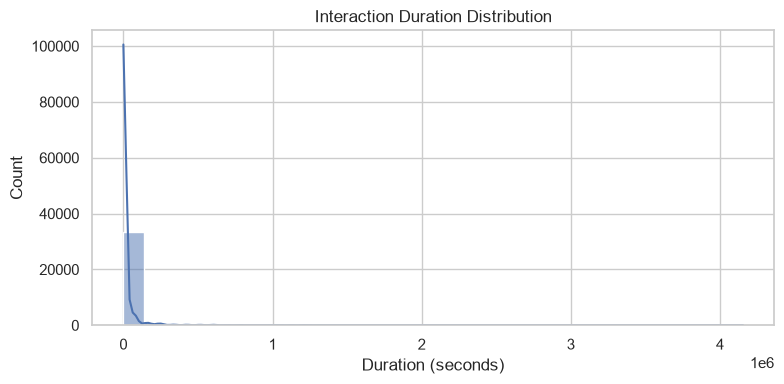

In [14]:
# 3️⃣ Interaction duration distribution (seconds)
if 'Duration_Seconds' in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['Duration_Seconds'].dropna(), bins=30, kde=True)
    plt.title('Interaction Duration Distribution')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

In [15]:
# 4️⃣ Top 10 queues by interaction count (if column exists)
if 'Queue_Name' in df.columns:
    top_queues = df['Queue_Name'].value_counts().nlargest(10)
    plt.figure(figsize=(8,4))
    top_queues.plot(kind='bar')
    plt.title('Top 10 Queues – Interaction Count')
    plt.xlabel('Queue')
    plt.ylabel('Interactions')
    plt.tight_layout()
    plt.show()

In [16]:
# 5️⃣ Top 10 agents by interaction count (if column exists)
if 'Agent_Name' in df.columns:
    top_agents = df['Agent_Name'].value_counts().nlargest(10)
    plt.figure(figsize=(8,4))
    top_agents.plot(kind='bar')
    plt.title('Top 10 Agents – Interaction Count')
    plt.xlabel('Agent')
    plt.ylabel('Interactions')
    plt.tight_layout()
    plt.show()